In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
# Load the HR dataset, customer_purchase_data, and sales_data.
HR = pd.read_csv("HR_Analytics_Dataset.csv")
Market = pd.read_csv("customer_purchase_data.csv")
sales= pd.read_csv("sales_data.csv")

# Load the HR dataset
file_path = "HR_Analytics_Dataset.csv"
df = pd.read_csv(file_path)

# graphs

print("HR Shape:", HR.shape)
print("Market Shape:", Market.shape)
print("sales Shape:", sales.shape)

HR.head()


HR Shape: (500, 6)
Market Shape: (1342, 8)
sales Shape: (2485, 6)


,employee_id,gender,department,years_at_company,promotion_last_5_years,left_company
0,1,Male,Marketing,15,No,No
1,2,Female,Marketing,5,No,No
2,3,Male,Sales,10,No,Yes
3,4,Male,HR,7,No,No
4,5,Male,IT,17,No,No


In [6]:
# Task 1 HR - ANALYTICS 
# QUESTION 1: Determine the proportion of employees who left the company within their first five years and compare this proportion across departments. Which departments experience the highest early-stage turnover?

In [7]:

#New columns and Transformations (Yes/N0 = 1,0) and who left beofre 5 years in house
HR["left_num"] = np.where(HR["left_company"] == "Yes" , 1, 0)
HR["promo_num"] = np.where(HR ["promotion_last_5_years"] == "Yes" , 1, 0)
HR["early_leaver"] = np.where ((HR ["left_company"]=="Yes") & (HR ["years_at_company"] <=5), 1, 0)
#Turnover by department group and sorting ASC
t = (HR.groupby("department")["early_leaver"]. mean()* 100). sort_values (ascending=False). round (2). reset_index ()
t. columns = ["Department", "Turnover (%) "]
t. index = range (1, len(t)+1)
print (t.to_string())
print ("Overall early-stage (<5y) turnover (%):", round(HR["early_leaver"]. mean ()*100, 2))


  Department  Turnover (%) 
1         HR           8.14
2      Sales           8.08
3         IT           6.36
4    Finance           5.49
5  Marketing           4.39
Overall early-stage (<5y) turnover (%): 6.4


In [8]:
#TASK 1 HR - ANALYTICS
#QUESTION 2: For employees who have worked at the company for at least 8 years, com-pare the turnover rates between those who have been promoted in thelast five years and those who have not. Does promotion appear to beassociated with retention among longer-tenured employees?

In [9]:
# Employees with at least 8 years in the company
long_tenure = HR[HR["years_at_company"] >= 8]

# Turnover comparison by promotion status
t2 = (long_tenure.groupby("promotion_last_5_years")["left_num"].mean() * 100).round(2).reset_index()

t2.columns = ["Promotion Status", "Turnover (%)"]
t2.index = range(1, len(t2) + 1)

print(t2.to_string())

# Overall turnover for long-tenured employees
print( "Overall turnover among employees with >=8 years (%):", round(long_tenure["left_num"].mean() * 100, 2))

# clear comparison
turn_no = t2.loc[t2["Promotion Status"] == "No", "Turnover (%)"].values[0]
turn_yes = t2.loc[t2["Promotion Status"] == "Yes", "Turnover (%)"].values[0]

print("\nComparison:")
print("Not promoted turnover (%):", turn_no)
print("Promoted turnover (%):", turn_yes)
print("Difference (No - Yes):", round(turn_no - turn_yes, 2))

  Promotion Status  Turnover (%)
1               No         21.27
2              Yes         22.45
Overall turnover among employees with >=8 years (%): 21.45

Comparison:
Not promoted turnover (%): 21.27
Promoted turnover (%): 22.45
Difference (No - Yes): -1.18


In [10]:
#TASK 1 HR - ANALYTICS
# QUESTION 3: Identify departments where employees who leave the company have, onaverage, spent more time at the company than employees who stay. Foreach department, compare the average tenure of leavers versus stayers and determine where this difference is the largest.

In [11]:
# Average tenure comparison: leavers vs stayers by department
t3 = ( HR.groupby(["department", "left_company"])["years_at_company"].mean() .unstack().round(2) .reset_index())

# Rename columns clearly
t3.columns = ["Department", "Stayed Avg Years", "Left Avg Years"]

# Calculate difference (Leavers - Stayers)
t3["Difference (Left - Stayed)"] = (t3["Left Avg Years"] - t3["Stayed Avg Years"]).round(2)

# Sort by largest difference
t3 = t3.sort_values("Difference (Left - Stayed)", ascending=False).reset_index(drop=True)
t3.index = range(1, len(t3) + 1)

print(t3.to_string())

# Identify department with largest gap
max_dept = t3.iloc[0]

print("\nDepartment with largest tenure gap:")
print("Department:", max_dept["Department"])
print("Difference:", max_dept["Difference (Left - Stayed)"])

  Department  Stayed Avg Years  Left Avg Years  Difference (Left - Stayed)
1    Finance              9.77           10.71                        0.94
2  Marketing              9.81           10.69                        0.88
3      Sales             10.92           10.32                       -0.60
4         HR             10.19            8.39                       -1.80
5         IT             10.94            8.90                       -2.04

Department with largest tenure gap:
Department: Finance
Difference: 0.94


In [12]:
# TASK 1 HR - ANALYTICS
#QUESTION 4: Examine whether employees who leave the company tend to do so shortly after a long period without promotion. Specifically, for employees who left, calculate the average tenure separately for those who were promoted in the last five years and those who were not, and compare the results across departments.

In [13]:
# Filter only employees who left
leavers = HR[HR["left_num"] == 1]

# Average tenure of leavers by department and promotion status
comp = (leavers.groupby(["department", "promo_num"])["years_at_company"].mean().round(2).reset_index())

# Label promotion status
comp["Promotion Status"] = np.where(comp["promo_num"] == 1, "Promoted", "Not Promoted")
comp = comp.drop("promo_num", axis=1)

# Pivot for clear department comparison
result = (comp.pivot(index="department",columns="Promotion Status", values="years_at_company").reset_index().round(2))

print(result.to_string(index=False))

department  Not Promoted  Promoted
   Finance         10.93      9.00
        HR          9.35      5.67
        IT          8.89      9.00
 Marketing         12.00      7.14
     Sales         10.38     10.17


In [14]:
# TASK 2 MARKETING ANALYTICS
# QUESTION 1: Analyze how total spending differs across customer groups defined by household size and membership status. Identify which combinations of household size and membership status are associated with the highest and lowest average total spending.

In [15]:
# CUSTOMER GROUPS AND HOUSEHOLD SIZE AND MEMBERSHIP STATUS

t = ( Market.groupby(["Household_Size", "Membership_Status"])["Total_Spending"].mean().round(2) .reset_index())

t.columns = ["Household Size", "Membership Status", "Avg Total Spending"]

# Sort to compare groups
t = t.sort_values("Avg Total Spending", ascending=False).reset_index(drop=True)

print(t.to_string(index=False))

# Highest and lowest groups
highest = t.iloc[0]
lowest = t.iloc[-1]

print("\nHighest average spending group:")
print(highest.to_string())

print("\nLowest average spending group:")
print(lowest.to_string())

 Household Size Membership Status  Avg Total Spending
              5            Member             5548.68
              4            Member             4406.16
              5        Non-Member             4018.54
              3            Member             3104.59
              4        Non-Member             2665.42
              3        Non-Member             2066.06
              2            Member             1892.34
              2        Non-Member             1201.75
              1            Member              948.48
              1        Non-Member              615.45

Highest average spending group:
Household Size              5
Membership Status      Member
Avg Total Spending    5548.68

Lowest average spending group:
Household Size                 1
Membership Status     Non-Member
Avg Total Spending        615.45


In [16]:
#TASK 2 MARKETING ANALYTICS
# QUESTION 2: Examine the relationship between customer age and total spending. Your analysis should make it possible to assess whether spending tends to increase, decrease, or vary non-linearly with age, and whether certain age ranges stand out in terms of spending behaviour.

In [17]:
# Correlation between Age and Total Spending
corr = Market["Age"].corr(Market["Total_Spending"])
print("Correlation between Age and Total Spending:", round(corr, 3))

# Average spending by exact age
age_avg = (Market.groupby("Age")["Total_Spending"] .mean().round(2).reset_index())

print(age_avg.head())

# Create age groups
Market["Age_Group"] = pd.cut(Market["Age"], bins=[0, 29, 39, 49, 59, 100], labels=["<30", "30-39", "40-49", "50-59", "60+"])

# Average spending by age group (FIXED)
age_group_spend = ( Market.groupby("Age_Group", observed=False)["Total_Spending"] .mean() .round(2) .reset_index() .sort_values("Total_Spending", ascending=False))

age_group_spend.columns = ["Age Group", "Avg Total Spending"]

print(age_group_spend.to_string(index=False))

# Identify highest and lowest age groups
highest_age = age_group_spend.iloc[0]
lowest_age = age_group_spend.iloc[-1]

print("\nHighest spending age group:")
print(highest_age.to_string())

print("\nLowest spending age group:")
print(lowest_age.to_string())

Correlation between Age and Total Spending: 0.311
   Age  Total_Spending
0   18         1665.58
1   19         1810.41
2   20         1898.31
3   21         2041.30
4   22         1769.24
Age Group  Avg Total Spending
      60+             3695.74
    50-59             3307.46
    40-49             3052.06
    30-39             2338.66
      <30             1910.16

Highest spending age group:
Age Group                 60+
Avg Total Spending    3695.74

Lowest spending age group:
Age Group                 <30
Avg Total Spending    1910.16


In [18]:
# TASK 2 MARKETING ANALYTICS
# QUESTION 3: Explore how total spending varies across regions, taking into account both the number of customers and their average spending levels. Based on your analysis, are regional differences in total spending driven more by customer volume or by spending intensity?

In [19]:
# Regional customer count and spending analysis
region_summary = (Market.groupby("Region").agg(    Customers=("Customer_ID", "count"), Avg_Spending=("Total_Spending", "mean"), Total_Spending=("Total_Spending", "sum") ) .round(2) .reset_index())

# Sort by total spending (most important business view)
region_summary = region_summary.sort_values("Total_Spending", ascending=False)

print(region_summary.to_string(index=False))

# Identify top and bottom regions
top_region = region_summary.iloc[0]
bottom_region = region_summary.iloc[-1]

print("Region with highest total spending:")
print(top_region.to_string())

print("Region with lowest total spending:")
print(bottom_region.to_string())

# Rank comparison
region_summary["Customer_Rank"] = region_summary["Customers"].rank(ascending=False)
region_summary["AvgSpend_Rank"] = region_summary["Avg_Spending"].rank(ascending=False)

print("Diagnostic table:")
print(region_summary.to_string(index=False))

Region  Customers  Avg_Spending  Total_Spending
  West        412       3095.51      1275348.55
 North        399       3020.61      1205225.01
  East        284       2232.93       634151.43
 South        247       2314.53       571689.98
Region with highest total spending:
Region                  West
Customers                412
Avg_Spending         3095.51
Total_Spending    1275348.55
Region with lowest total spending:
Region                South
Customers               247
Avg_Spending        2314.53
Total_Spending    571689.98
Diagnostic table:
Region  Customers  Avg_Spending  Total_Spending  Customer_Rank  AvgSpend_Rank
  West        412       3095.51      1275348.55            1.0            1.0
 North        399       3020.61      1205225.01            2.0            2.0
  East        284       2232.93       634151.43            3.0            4.0
 South        247       2314.53       571689.98            4.0            3.0


In [20]:
#TASK 2 MARKETING ANALYTICS
# QUESTION 4: Use an appropriate visual representation to compare total spending patterns across membership status and regions simultaneously. The visualisation should support a clear comparison.

Region Membership Status  Avg Total Spending
  East            Member         2582.851648
  East        Non-Member         1608.553235
 North            Member         3434.874746
 North        Non-Member         2420.825583
 South            Member         2627.184575
 South        Non-Member         1805.646170
  West            Member         3583.074096
  West        Non-Member         2350.693865


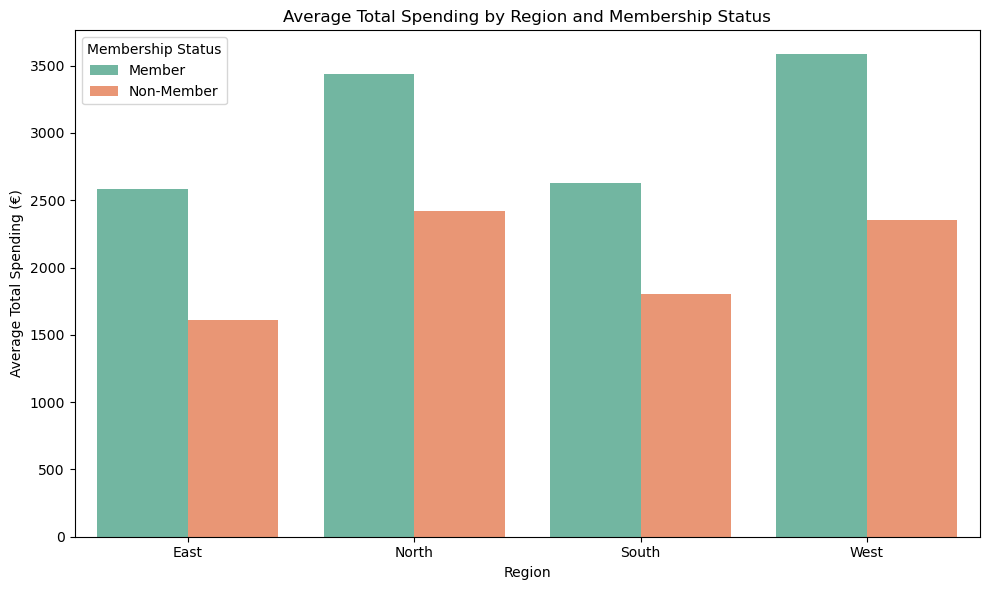

In [21]:
# Step 1: Aggregate total spending by Region and Membership Status
spending_summary = Market.groupby(["Region", "Membership_Status"])["Total_Spending"].mean().reset_index()
spending_summary.columns = ["Region", "Membership Status", "Avg Total Spending"]

# Step 2: Sort for better readability
spending_summary = spending_summary.sort_values(["Region", "Avg Total Spending"], ascending=[True, False])
print(spending_summary.to_string(index=False))

# Step 3: Visualisation - Grouped Bar Chart
plt.figure(figsize=(10,6))
sns.barplot(data=spending_summary, x="Region", y="Avg Total Spending", hue="Membership Status", palette="Set2")

plt.title("Average Total Spending by Region and Membership Status")
plt.ylabel("Average Total Spending (€)")
plt.xlabel("Region")
plt.legend(title="Membership Status")
plt.tight_layout()
plt.show()


In [22]:
# TASK 2 MARKETING ANALYTICS
# QUESTION 5:  Create a visualisation that helps identify differences in purchasing be-haviour between customers with low, medium, and high total spending.You should define reasonable thresholds for these spending groups yourself.

Customer Spending Summary by Group:

                count     mean         sum
Spending_Group                            
High              490  4929.90  2415650.88
Low               292   683.67   199631.18
Medium            560  1912.74  1071132.91


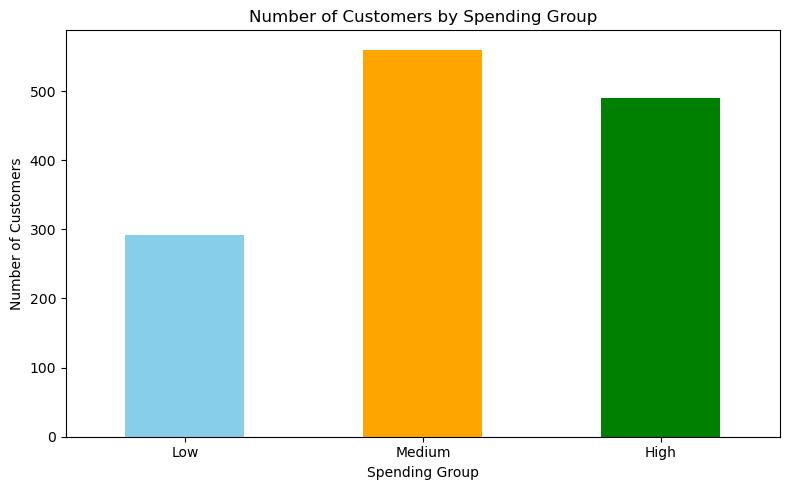

In [23]:
# Step 1: Define spending groups with your thresholds
def spending_group(spend):
    if spend <= 999:
        return "Low"
    elif spend <= 2999:
        return "Medium"
    else:
        return "High"

# Step 2: Create Spending_Group column
Market["Spending_Group"] = Market["Total_Spending"].apply(spending_group)

# Step 3: Summary table for clarity
group_summary = Market.groupby("Spending_Group")["Total_Spending"].agg(["count", "mean", "sum"]).round(2)
print("Customer Spending Summary by Group:\n")
print(group_summary)

# Step 4: Simple bar chart to show number of customers in each group
customer_counts = Market["Spending_Group"].value_counts().reindex(["Low","Medium","High"])

plt.figure(figsize=(8,5))
customer_counts.plot(kind="bar", color=["skyblue","orange","green"])
plt.title("Number of Customers by Spending Group")
plt.xlabel("Spending Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# TASK 3 SALES ANALYTICS
# STEP 1: Explore Monthly Sales by Region
# I want to see which regions contribute most to revenue.

Total Sales by Region:
 Region
North    15625452
West     14343819
East      7247576
South     6854830
Name: Monthly_Sales, dtype: int64


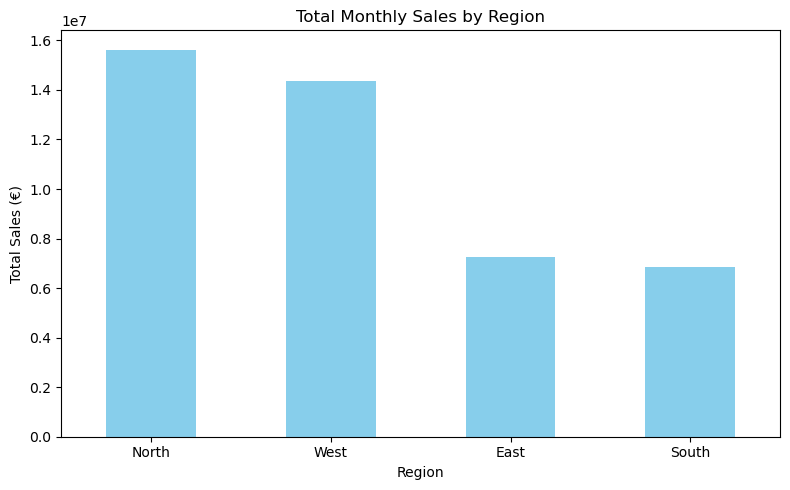

In [30]:
# Aggregate monthly sales by region
region_sales = sales.groupby("Region")["Monthly_Sales"].sum().sort_values(ascending=False).round(2)
print("Total Sales by Region:\n", region_sales)

# Visualization
plt.figure(figsize=(8,5))
region_sales.plot(kind="bar", color="skyblue")
plt.title("Total Monthly Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales (€)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
# STEP 2: Check Revenue Concentration by Store
# I check if revenue is dominated by a few stores.

Top 10 Stores by Revenue:
 Store_ID
885     279144
884     224778
1195    224550
1649    217938
598     197556
133     186318
235     165468
347     155376
1210    131946
391     120252
Name: Monthly_Sales, dtype: int64


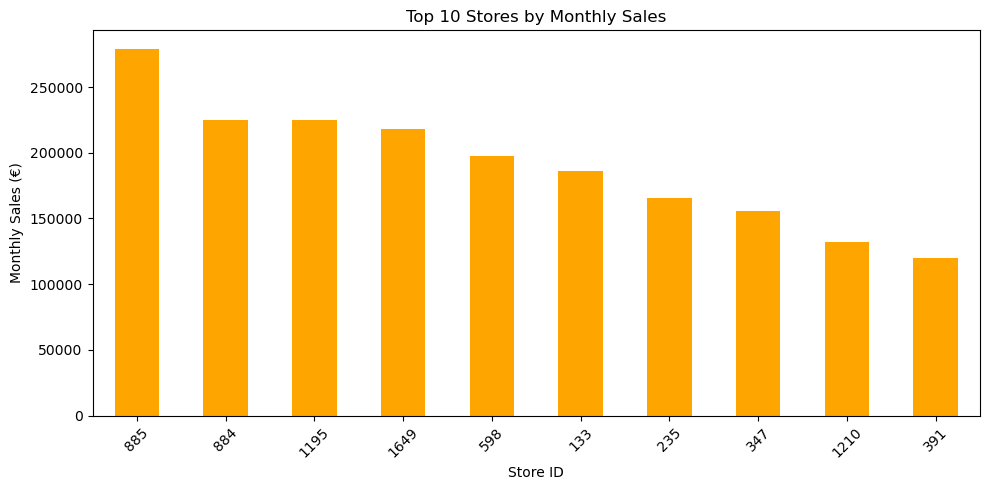

In [32]:

# Top 10 stores by revenue
top_stores = sales.groupby("Store_ID")["Monthly_Sales"].sum().sort_values(ascending=False).head(10)
print("Top 10 Stores by Revenue:\n", top_stores)

# Visualization
plt.figure(figsize=(10,5))
top_stores.plot(kind="bar", color="orange")
plt.title("Top 10 Stores by Monthly Sales")
plt.xlabel("Store ID")
plt.ylabel("Monthly Sales (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
# STEP 3:Sales vs. Footfall & Store Area
# I want to see if bigger stores or stores with more customers make more sales.

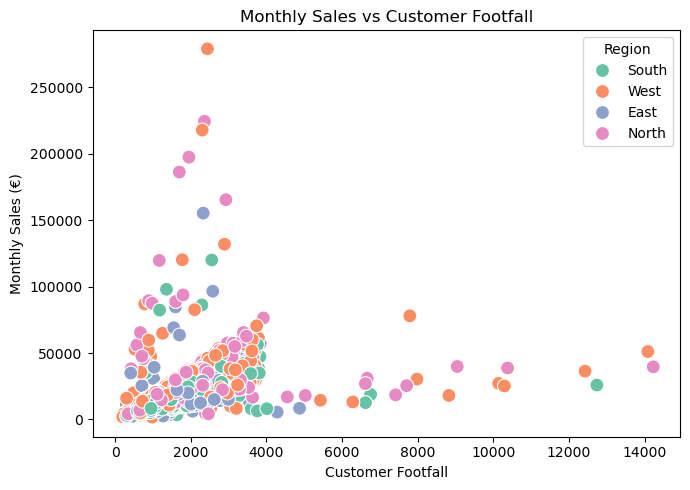

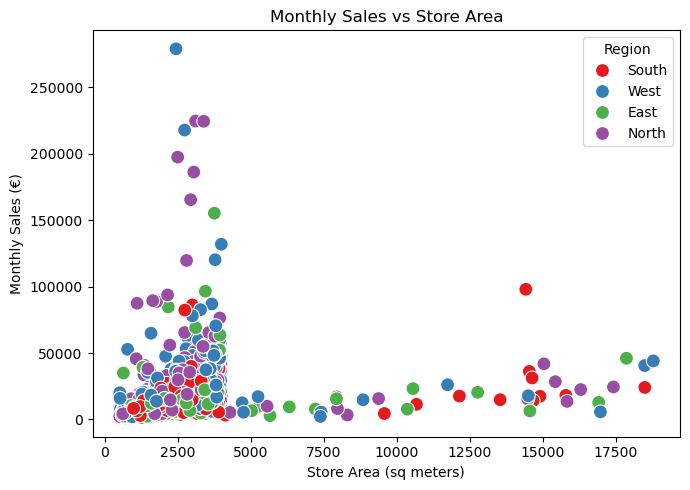

In [34]:

# Scatter plot for Sales vs Customer Footfall
plt.figure(figsize=(7,5))
sns.scatterplot(data=sales, x="Customer_Footfall", y="Monthly_Sales", hue="Region", palette="Set2", s=100)
plt.title("Monthly Sales vs Customer Footfall")
plt.xlabel("Customer Footfall")
plt.ylabel("Monthly Sales (€)")
plt.tight_layout()
plt.show()

# Scatter plot for Sales vs Store Area
plt.figure(figsize=(7,5))
sns.scatterplot(data=sales, x="Store_Area", y="Monthly_Sales", hue="Region", palette="Set1", s=100)
plt.title("Monthly Sales vs Store Area")
plt.xlabel("Store Area (sq meters)")
plt.ylabel("Monthly Sales (€)")
plt.tight_layout()
plt.show()

In [35]:
#Step 5: Revenue per Employee
# Check efficiency of stores in generating revenue relative to staff size.

Top 10 Stores by Sales per Employee:
       Store_ID Region  Monthly_Sales  Number_of_Employees  Sales_per_Employee
884        885   West         279144                 28.0             9969.43
1648      1649   West         217938                 28.0             7783.50
597        598  North         197556                 30.0             6585.20
883        884  North         224778                 38.0             5915.21
132        133  North         186318                 32.0             5822.44
1194      1195  North         224550                 42.0             5346.43
2249      2250  North          87510                 17.0             5147.65
234        235  North         165468                 36.0             4596.33
519        520  North          88776                 20.0             4438.80
2348      2349   East          34926                  8.0             4365.75


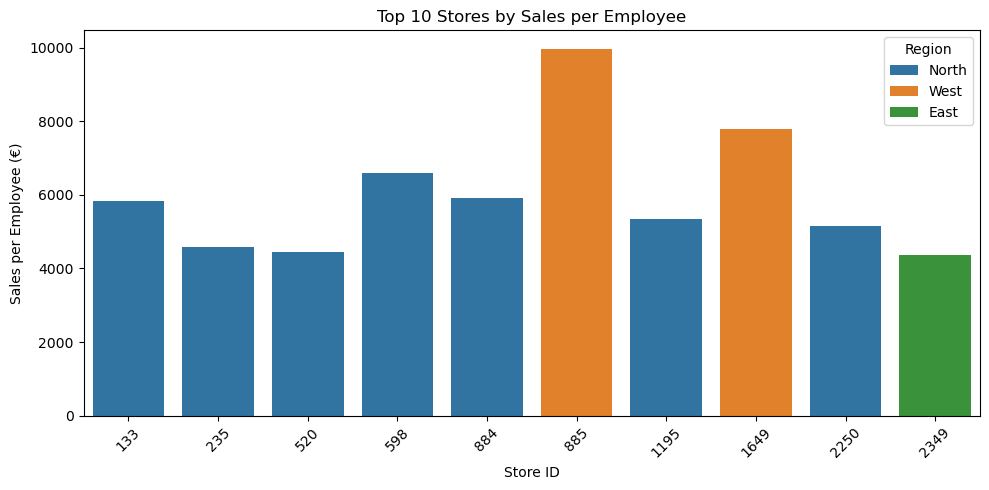

In [36]:

# Calculate revenue per employee
sales["Sales_per_Employee"] = (sales["Monthly_Sales"] / sales["Number_of_Employees"]).round(2)

# Top stores by efficiency
top_efficiency = sales.sort_values("Sales_per_Employee", ascending=False).head(10)
print("Top 10 Stores by Sales per Employee:\n", top_efficiency[["Store_ID","Region","Monthly_Sales","Number_of_Employees","Sales_per_Employee"]])

# Visualization
plt.figure(figsize=(10,5))
sns.barplot(data=top_efficiency, x="Store_ID", y="Sales_per_Employee", hue="Region")
plt.title("Top 10 Stores by Sales per Employee")
plt.xlabel("Store ID")
plt.ylabel("Sales per Employee (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()